# Desafío - Preparación de datos y gráficos

### Descripción
La base de datos world-data-2023.csv proporciona una gran cantidad de información sobre
todos los países del mundo, abarcando una amplia gama de indicadores y atributos. Incluye
estadísticas demográficas, indicadores económicos, factores ambientales, métricas de
atención médica, estadísticas educativas y mucho más. Con la representación de cada país,
este conjunto de datos ofrece una perspectiva global completa sobre diversos aspectos de
las naciones, lo que permite análisis en profundidad y comparaciones entre países. 

1. Carga los datos y genera un dataFrame que excluya las columnas correspondientes
a la abreviatura del país, código de llamada, capital, código de moneda, ciudad más
grande, lenguaje oficial, latitud y longitud. Considerando estos datos, realiza una
inspección inicial sobre ellos, considerando gráficos. Concluye.

In [1]:
# Primero vamos a importar las librerías que vamos a usar.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Cargamos el archivo CSV.
df = pd.read_csv("world-data-2023.csv")

# Mostramos las primeras filas para ver la estructura.
df.head()

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


In [3]:
# Mostramos los nombres de las columnas.
df.columns

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

In [4]:
# Creamos una lista con las columnas que queremos eliminar.
columnas_a_eliminar = [
    'Abbreviation',
    'Calling Code',
    'Capital/Major City',
    'Currency-Code',
    'Largest city',
    'Official language',
    'Latitude',
    'Longitude'
]

# Creamos el nuevo dataframe y eliminamos las columnas de la lista.
df2 = df.drop(columns=columnas_a_eliminar)

# Mostramos el nuevo dataframe.
df2

,Country,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,...,Maternal mortality ratio,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,Afghanistan,60,58.10%,"652,230","323,000",32.49,"8,672",149.9,2.30%,4.47,...,638.0,$0.43,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273"
1,Albania,105,43.10%,"28,748","9,000",11.78,"4,536",119.05,1.40%,1.62,...,15.0,$1.12,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593"
2,Algeria,18,17.40%,"2,381,741","317,000",24.28,"150,006",151.36,2.00%,3.02,...,112.0,$0.95,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100"
3,Andorra,164,40.00%,468,NaN,7.20,469,NaN,NaN,1.27,...,NaN,$6.63,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873"
4,Angola,26,47.50%,"1,246,700","117,000",40.73,"34,693",261.73,17.10%,5.52,...,241.0,$0.71,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,32,24.50%,"912,050","343,000",17.88,"164,175","2,740.27",254.90%,2.27,...,125.0,$0.01,45.80%,1.92,"28,515,829",59.70%,NaN,73.30%,8.80%,"25,162,368"
191,Vietnam,314,39.30%,"331,210","522,000",16.75,"192,668",163.52,2.80%,2.05,...,43.0,$0.73,43.50%,0.82,"96,462,106",77.40%,19.10%,37.60%,2.01%,"35,332,140"
192,Yemen,56,44.60%,"527,968","40,000",30.45,"10,609",157.58,8.10%,3.79,...,164.0,NaN,81.00%,0.31,"29,161,922",38.00%,NaN,26.60%,12.91%,"10,869,523"
193,Zambia,25,32.10%,"752,618","16,000",36.19,"5,141",212.31,9.20%,4.63,...,213.0,$0.24,27.50%,1.19,"17,861,030",74.60%,16.20%,15.60%,11.43%,"7,871,713"


In [5]:
# Hacemos una pequeña inspección de los datos.

#Primero revisamos los nulos.
df2.isnull().sum()

Country                                       0
Density\n(P/Km2)                              0
Agricultural Land( %)                         7
Land Area(Km2)                                1
Armed Forces size                            24
Birth Rate                                    6
Co2-Emissions                                 7
CPI                                          17
CPI Change (%)                               16
Fertility Rate                                7
Forested Area (%)                             7
Gasoline Price                               20
GDP                                           2
Gross primary education enrollment (%)        7
Gross tertiary education enrollment (%)      12
Infant mortality                              6
Life expectancy                               8
Maternal mortality ratio                     14
Minimum wage                                 45
Out of pocket health expenditure              7
Physicians per thousand                 

In [6]:
# Vemos algunas variables estadísticas.
df2.describe()

,Birth Rate,Fertility Rate,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand
count,189.000000,188.000000,189.000000,187.000000,181.000000,188.000000
mean,20.214974,2.698138,21.332804,72.279679,160.392265,1.839840
std,9.945774,1.282267,19.548058,7.483661,233.502024,1.684261
min,5.900000,0.980000,1.400000,52.800000,2.000000,0.010000
25%,11.300000,1.705000,6.000000,67.000000,13.000000,0.332500
50%,17.950000,2.245000,14.000000,73.200000,53.000000,1.460000
75%,28.750000,3.597500,32.700000,77.500000,186.000000,2.935000
max,46.080000,6.910000,84.500000,85.400000,1150.000000,8.420000


In [7]:
# Revisamos los duplicados.
df2.duplicated().sum()

np.int64(0)

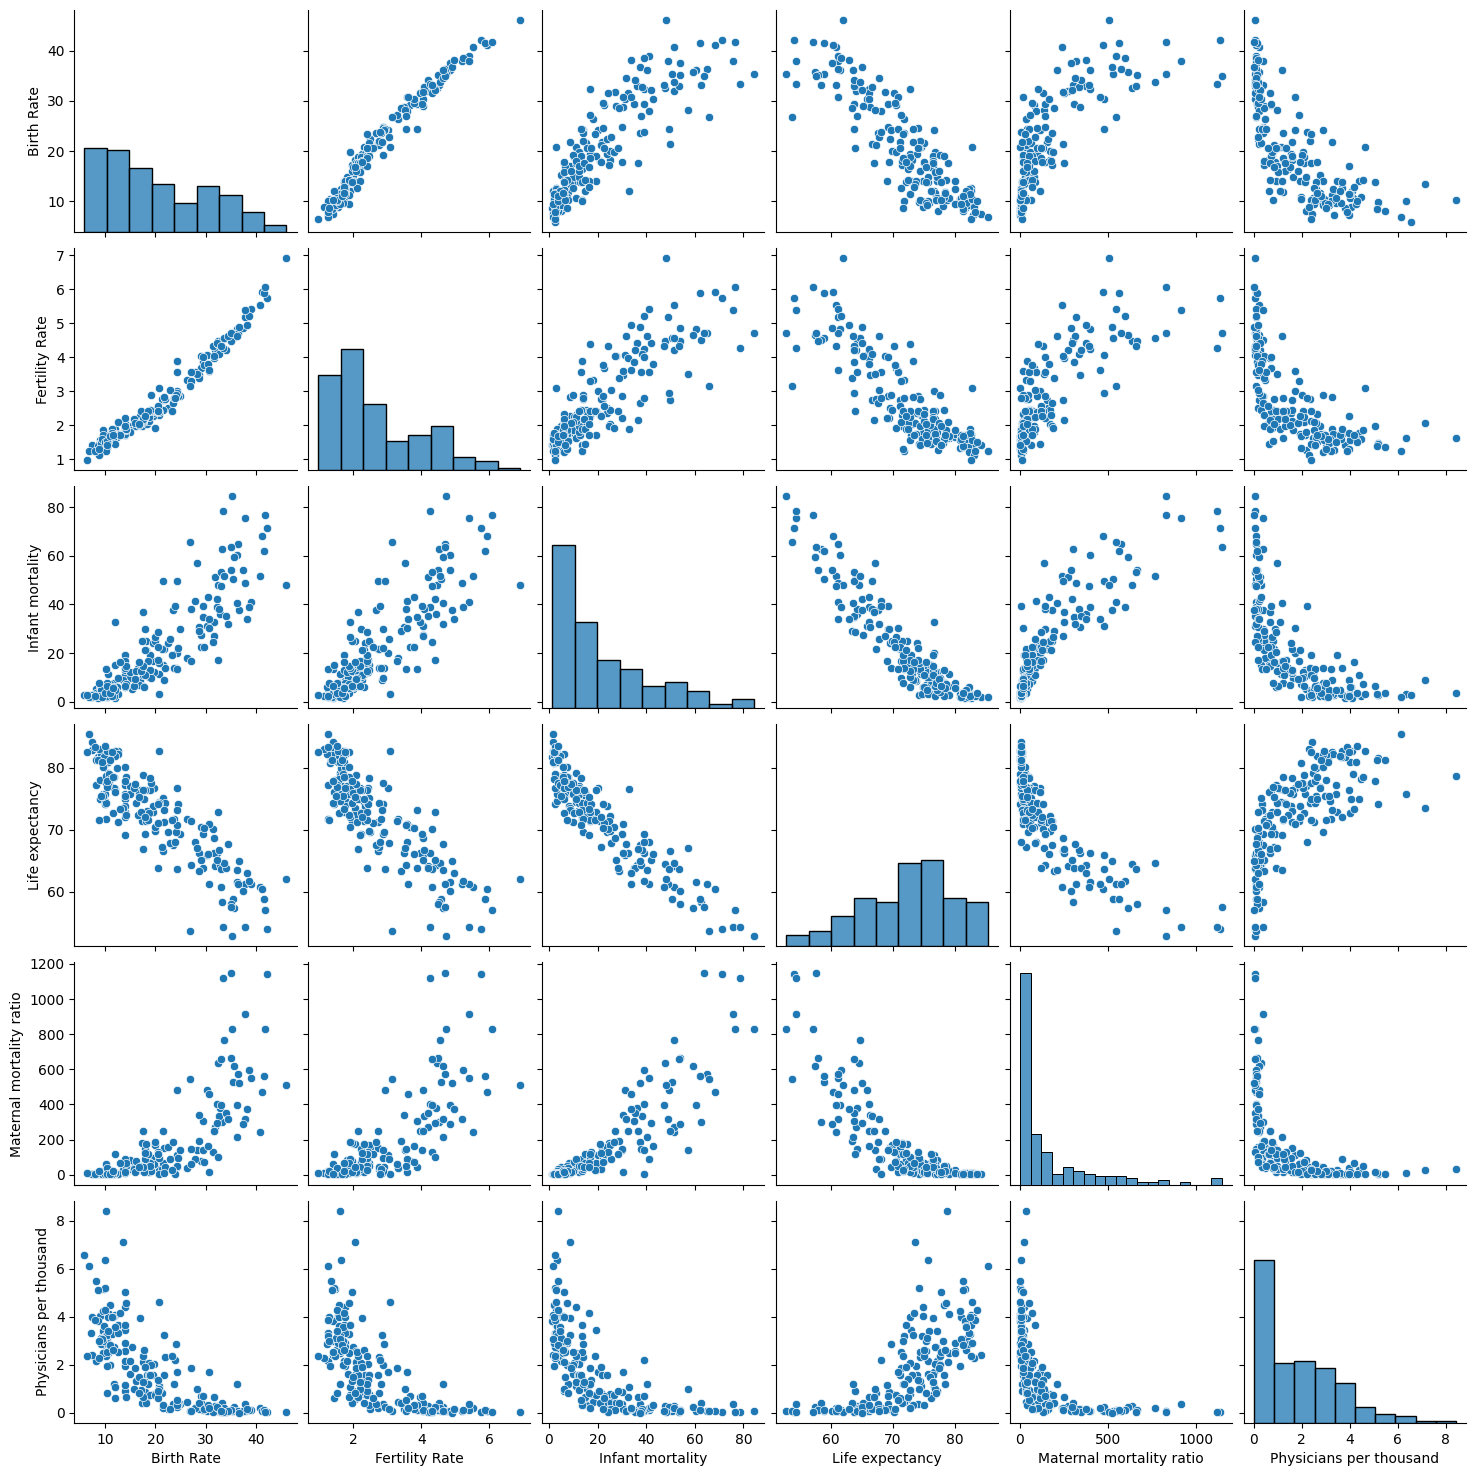

In [8]:
# Realizamos un gráfico de las columnas de dataframe.
sns.pairplot(df2)
plt.show()

In [9]:
# Podemos observar que hay variables que no se incluyeron en los gráficos, vamos a revisar el tipo de dato de las columnas.
df2.dtypes

Country                                       object
Density\n(P/Km2)                              object
Agricultural Land( %)                         object
Land Area(Km2)                                object
Armed Forces size                             object
Birth Rate                                   float64
Co2-Emissions                                 object
CPI                                           object
CPI Change (%)                                object
Fertility Rate                               float64
Forested Area (%)                             object
Gasoline Price                                object
GDP                                           object
Gross primary education enrollment (%)        object
Gross tertiary education enrollment (%)       object
Infant mortality                             float64
Life expectancy                              float64
Maternal mortality ratio                     float64
Minimum wage                                  

2. De las variables codificadas numéricamente, ¿hay pares de ellas en la que parezca
haber correlación? ¿Para cuál(es) de ellas se observa más claramente?

#### Conclusión de los puntos 1 y 2:
El análisis inicial se realizó utilizando únicamente las variables que se encuentran correctamente tipadas como datos numéricos en el dataset.
Estas variables abarcan principalmente indicadores de salud y demografía: 
tasa de natalidad (Birth Rate), tasa de fertilidad (Fertility Rate), mortalidad infantil (Infant Mortality), esperanza de vida (Life Expectancy),
razón de mortalidad materna (Maternal Mortality Ratio) y cantidad de médicos por mil habitantes (Physicians per Thousand).

El pairplot permitió visualizar las siguentes relaciones entre estos indicadores:
-Se observa una clara relación negativa entre la esperanza de vida y la mortalidad infantil. 
-La tasa de fertilidad y la tasa de natalidad muestran una relación positiva, 
reflejando patrones demográficos típicos donde poblaciones con mayor natalidad también presentan mayor número de hijos por mujer.
-Se aprecia que la cantidad de médicos por mil habitantes suele relacionarse negativamente con la mortalidad materna e infantil, 
indicando que una mayor disponibilidad de personal médico contribuye a mejores resultados en salud. 

En conjunto, este análisis visual preliminar ofrece una primera aproximación a los niveles de desarrollo sanitario global. 
En etapas posteriores, con la conversión de más columnas a formato numérico permitirá ampliar y profundizar este estudio comparativo entre países.

3. Considera los dos pares de variables anteriores y elimina en cada caso los faltantes
y atípicos. Justifica en cada caso tu procedimiento.

In [10]:
# Las variables elegidas son: Birth Rate (tasa de natalidad), Fertility Rate (tasa de fertilidad),
# Life Expectancy (esperanza de vida) y Infant Mortality (mortalidad infantil).

# Seleccionamos las columnas.
cols = ["Birth Rate", "Fertility Rate", "Life expectancy", "Infant mortality"]

# Creamos un nuevo dataframe con las columnas de interés.
df3 = df2[cols].copy()

# Eliminamos los faltantes.
df3 = df3.dropna()

In [11]:
# Función para eliminar Outliers (IQR).
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[column] >= limite_inferior) & (df[column] <= limite_superior)].copy()
    return df_filtered

In [12]:
# Aplicamos la función a cada variable con un ciclo for.
for col in df3.columns:
    df3 = remove_outliers_iqr(df3, col)

# Mostramos parte de dataframe resultante.
df3.head()

,Birth Rate,Fertility Rate,Life expectancy,Infant mortality
0,32.49,4.47,64.5,47.9
1,11.78,1.62,78.5,7.8
2,24.28,3.02,76.7,20.1
4,40.73,5.52,60.8,51.6
5,15.33,1.99,76.9,5.0


#### Justificación
Los valores faltantes fueron eliminados únicamente en el DataFrame creado para analizar las variables seleccionadas. 
Esta decisión permite trabajar con datos completos sin modificar el dataset original,
preservando su integridad y evitando introducir sesgos al análisis general.

4. Construye un gráfico para verificar la correlación entre estas variables, ahora con los
datos preparados. Compara con lo obtenido anteriormente.

In [13]:
# Primero vamos a calcular la correlación antes de la limpieza.

df_sucio = df2[cols]  #cols = ["Birth Rate", "Fertility Rate", "Life expectancy", "Infant mortality"]
corr_sucio = df_sucio.corr()

print("Correlación ANTES de limpiar:")
corr_sucio

Correlación ANTES de limpiar:


,Birth Rate,Fertility Rate,Life expectancy,Infant mortality
Birth Rate,1.000000,0.981069,-0.874747,0.867456
Fertility Rate,0.981069,1.000000,-0.849153,0.852653
Life expectancy,-0.874747,-0.849153,1.000000,-0.924675
Infant mortality,0.867456,0.852653,-0.924675,1.000000


In [14]:
# Calculamos la correlación después de limpiar.
corr3 = df3.corr()

print("\nCorrelación DESPUÉS de limpiar:")
corr3


Correlación DESPUÉS de limpiar:


,Birth Rate,Fertility Rate,Life expectancy,Infant mortality
Birth Rate,1.000000,0.981020,-0.870444,0.871013
Fertility Rate,0.981020,1.000000,-0.844644,0.853665
Life expectancy,-0.870444,-0.844644,1.000000,-0.914746
Infant mortality,0.871013,0.853665,-0.914746,1.000000


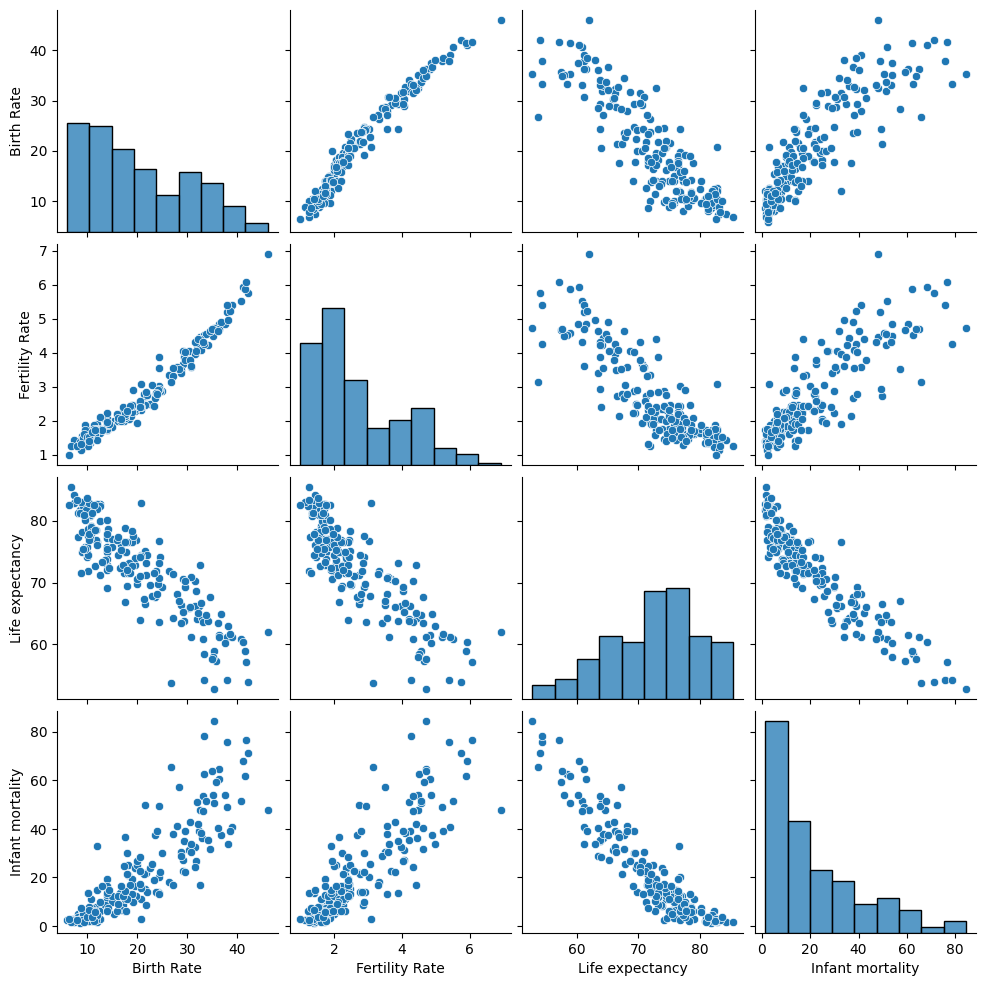

In [15]:
# Ahora vamos a contruir los gráficos.

#Para antes de la limpieza:
sns.pairplot(df_sucio)
plt.show()

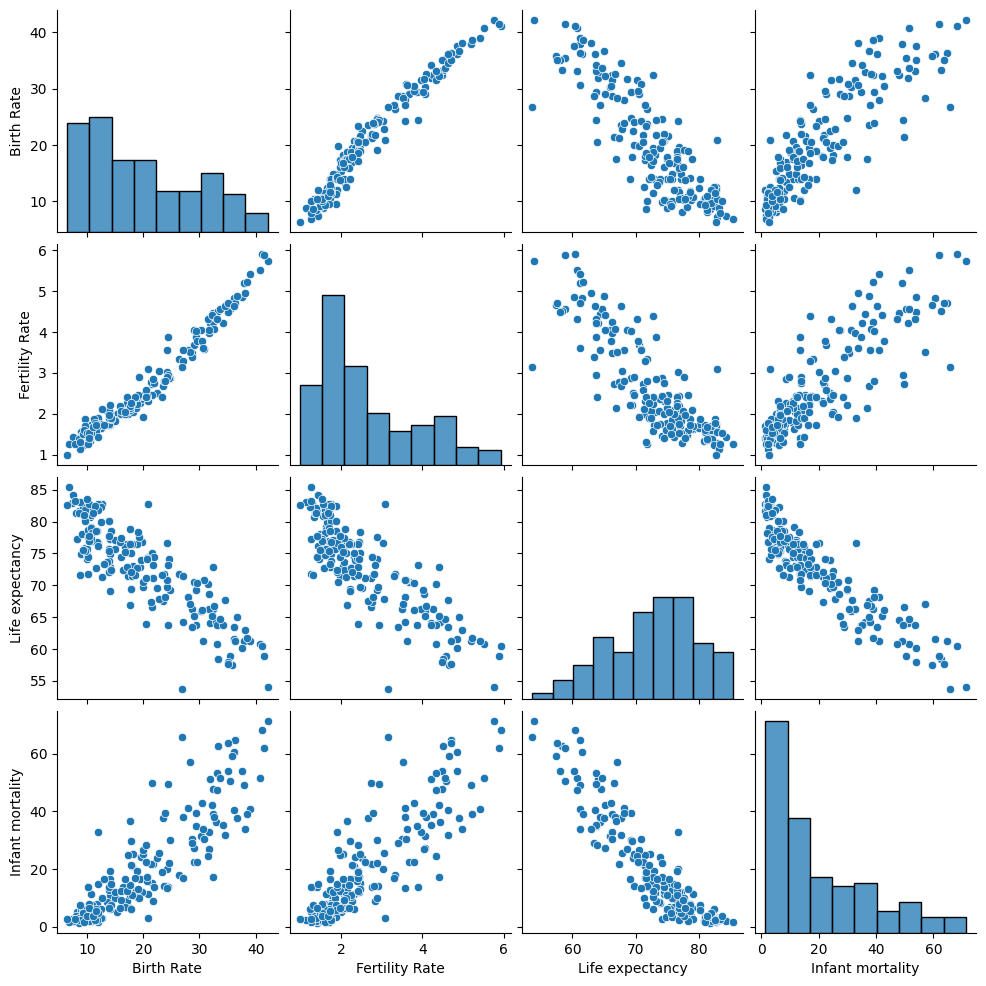

In [16]:
#Para antes de la limpieza:
sns.pairplot(df3)
plt.show()

#### Conclusión
Para evaluar el impacto de la limpieza se compararon pairplots y matrices de correlación antes y después del proceso.
La estructura general de las relaciones entre variables se mantuvo, aunque la limpieza permitió reducir ruido y estabilizar algunos valores.
Por ejemplo, la correlación entre Birth Rate e Infant Mortality, fuertemente positiva, aumentó ligeramente de 0.867456 a 0.871013 luego de eliminar outliers y registros inconsistentes.
Esto indica que el proceso de limpieza mejoró la calidad estadística del dataset, reforzando relaciones que ya eran evidentes sin alterar la tendencia global.

5. Realiza lo mismo para comparar la cantidad de médicos por cada mil personas y la
esperanza de vida. ¿Qué puedes concluir?

In [17]:
# Seleccionamos las columnas.
cols2 = ["Physicians per thousand", "Life expectancy"]

# Creamos un nuevo dataframe con las columnas de interés.
df4_sucio = df2[cols2].copy()

# Eliminamos los faltantes.
df4 = df4_sucio.dropna()

In [18]:
# Aplicamos la función a cada variable con un ciclo for.
for col in df4.columns:
    df4 = remove_outliers_iqr(df4, cols2)

# Mostramos parte de dataframe resultante.
df4.head()

,Physicians per thousand,Life expectancy
0,0.28,64.5
1,1.20,78.5
2,1.72,76.7
4,0.21,60.8
5,2.76,76.9


In [19]:
# Primero vamos a calcular la correlación antes de la limpieza.
corr_sucio4 = df4_sucio.corr()

print("Correlación ANTES de limpiar:")
corr_sucio4

Correlación ANTES de limpiar:


,Physicians per thousand,Life expectancy
Physicians per thousand,1.00000,0.70374
Life expectancy,0.70374,1.00000


In [20]:
# Calculamos la correlación después de limpiar.
corr4 = df4.corr()

print("\nCorrelación DESPUÉS de limpiar:")
corr4


Correlación DESPUÉS de limpiar:


,Physicians per thousand,Life expectancy
Physicians per thousand,1.000000,0.738343
Life expectancy,0.738343,1.000000


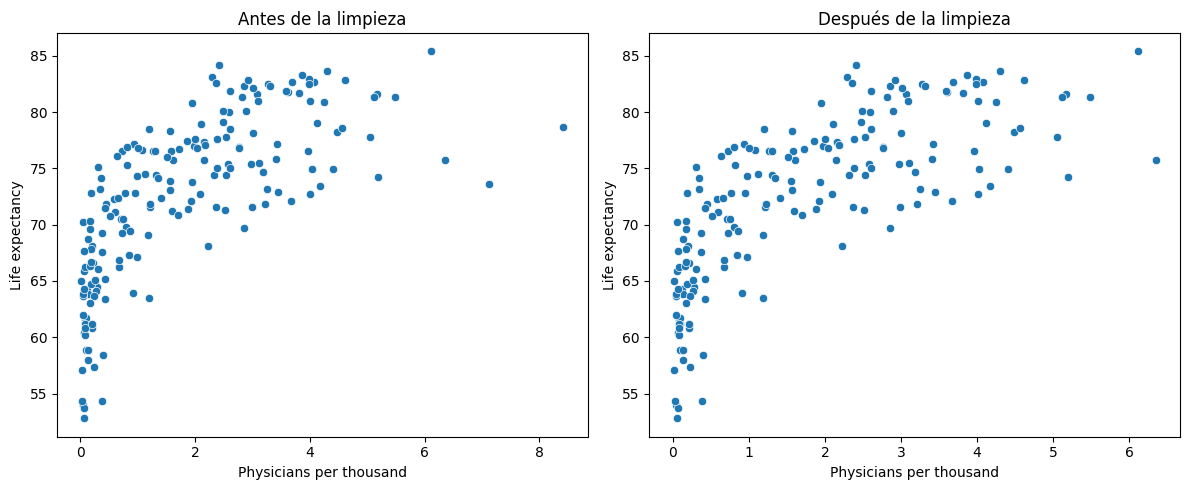

In [21]:
# Variables que vamos a analizar.
x = "Physicians per thousand"
y = "Life expectancy"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- ANTES ---
sns.scatterplot(
    data=df4_sucio,   #df antes de la limpieza.
    x=x, 
    y=y, 
    ax=axes[0]
)
axes[0].set_title("Antes de la limpieza")

# --- DESPUÉS ---
sns.scatterplot(
    data=df4,    #df limpio.
    x=x, 
    y=y, 
    ax=axes[1]
)
axes[1].set_title("Después de la limpieza")

plt.tight_layout()
plt.show()

#### Conclusión:
La correlación entre la cantidad de médicos por cada mil habitantes y la esperanza de vida pasó de 0.70374 antes de la limpieza a 0.738343 después de la limpieza.
Este aumento nos indica que, una vez eliminados los datos faltantes y los valores atípicos, la relación positiva entre ambas variables se vuelve más clara y consistente.
Los datos depurados nos muestran que a mayor disponibilidad de médicos, mayor es la esperanza de vida, lo cual coincide con lo esperado desde el punto de vista sanitario.
La limpieza no modificó la tendencia general, pero sí permitió obtener una relación más fuerte y menos afectada por ruido o registros anómalos.

6. Construye un gráfico para representar la población total de los países y su producto
interno bruto. Prepara los datos y escoge el gráfico adecuado (si es necesario, limpia
y/o transforma los datos). Justifica.

In [22]:
# Primero vamos a ver el tipo de dato que tienen las columnas para ver si necesitamos hacer alguna transformación.
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 27 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    object 
 2   Agricultural Land( %)                      188 non-null    object 
 3   Land Area(Km2)                             194 non-null    object 
 4   Armed Forces size                          171 non-null    object 
 5   Birth Rate                                 189 non-null    float64
 6   Co2-Emissions                              188 non-null    object 
 7   CPI                                        178 non-null    object 
 8   CPI Change (%)                             179 non-null    object 
 9   Fertility Rate                             188 non-null    float64
 10  Forested Area (%)         

In [23]:
# Seleccionamos las columnas.
df_pg = df[["Population", "GDP"]].copy()

# Mostramos parte del dataframe.
df_pg.head(5)

,Population,GDP
0,"38,041,754","$19,101,353,833"
1,"2,854,191","$15,278,077,447"
2,"43,053,054","$169,988,236,398"
3,"77,142","$3,154,057,987"
4,"31,825,295","$94,635,415,870"


In [24]:
# Limpiamos Population (quitamos comas y convertimos a número).
df_pg["Population"] = (df_pg["Population"]
                       .astype(str)
                       .str.replace(",", "")
                       .str.strip()) # Eliminamos los espacios en blanco en los extremos.

df_pg["Population"] = pd.to_numeric(df_pg["Population"], errors="coerce")

# Limpiamos GDP (quitamos $ y comas) y despúes convertimos a número.
df_pg["GDP"] = (df_pg["GDP"]
                .astype(str)
                .str.replace("$", "")
                .str.replace(",", "")
                .str.strip())

df_pg["GDP"] = pd.to_numeric(df_pg["GDP"], errors="coerce")

# Eliminamos las filas que quedaron vacías.
df_pg = df_pg.dropna()

# Nos aseguramos de que se haya convertido a número y que se hayan eliminado los $ y las comas.
df_pg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 0 to 194
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Population  193 non-null    float64
 1   GDP         193 non-null    float64
dtypes: float64(2)
memory usage: 4.5 KB


In [25]:
df_pg.head()

,Population,GDP
0,38041754.0,1.910135e+10
1,2854191.0,1.527808e+10
2,43053054.0,1.699882e+11
3,77142.0,3.154058e+09
4,31825295.0,9.463542e+10


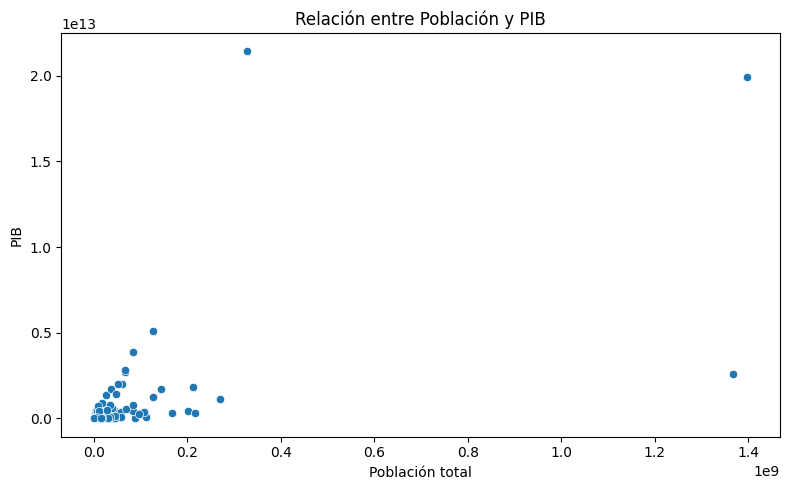

In [40]:
# Graficamos.
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_pg, x="Population", y="GDP")
plt.title("Relación entre Población y PIB")
plt.xlabel("Población total")
plt.ylabel("PIB")
plt.tight_layout()
plt.show()

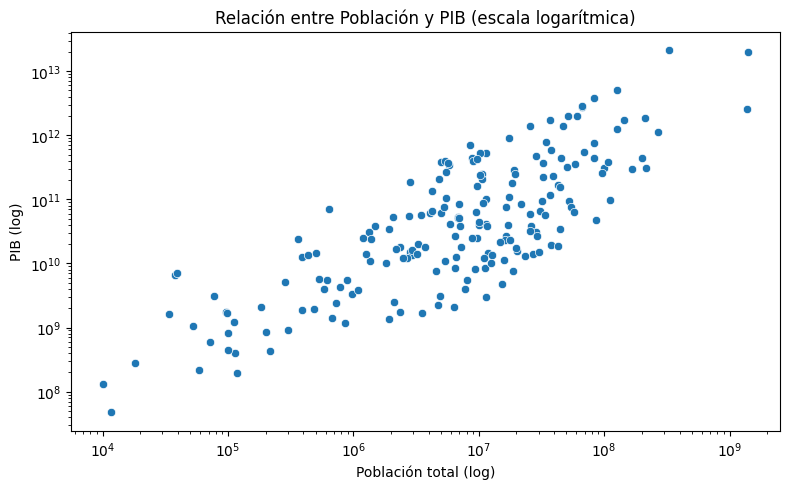

In [27]:
# Graficamos con escala logarítmica.
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_pg, x="Population", y="GDP")
plt.xscale("log")
plt.yscale("log")
plt.title("Relación entre Población y PIB (escala logarítmica)")
plt.xlabel("Población total (log)")
plt.ylabel("PIB (log)")
plt.tight_layout()
plt.show()

#### Conclusión: 
Se utilizó una escala logarítmica en ambos ejes debido a la amplia variación en los valores de Población y PBI entre países. Esta transformación permite representar datos que difieren en varios órdenes de magnitud, evita la distorsión visual causada por valores extremos y facilita identificar patrones, correlaciones y diferencias en la distribución.
Además, no se eliminaron los valores atípicos porque estos valores no son errores ni mediciones anómalas, sino ejemplos representativos de la desigual distribución de la población y del poder económico en el mundo. Excluirlos hubiese distorsionado el análisis y ocultado parte importante de la dinámica real entre ambas variables.
Al observar el gráfico en escala logarítmica, se aprecia que la relación entre Población y PBI no es lineal, porque el crecimiento económico no depende únicamente del tamaño de la población. Factores como la productividad por habitante, el desarrollo económico, la tecnología y la estructura productiva generan grandes diferencias entre países, haciendo que el PBI crezca a un ritmo distinto al crecimiento poblacional.

7. Escoge otro par de datos, límpialos, prepáralos y analiza su posible relación. Justifica
utilizando las herramientas vistas y gráficos adecuados.

#### Selección de variables, elegimos:
CO2-Emissions: emisiones totales de dióxido de carbono por país.
GDP: Producto Bruto Interno.
El objetivo es analizar si existe relación entre la actividad económica de un país y la cantidad de emisiones que genera.

In [29]:
# Comenzamos creando un dataframe con esas columnas.
df_cg = df[["Co2-Emissions", "GDP"]].copy()

# Vemos el tipo de variables y parte del dataframe para ver si es necesario limpiar y convertir.
df_cg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Co2-Emissions  188 non-null    object
 1   GDP            193 non-null    object
dtypes: object(2)
memory usage: 3.2+ KB


In [30]:
df_cg.head(5)

,Co2-Emissions,GDP
0,"8,672","$19,101,353,833"
1,"4,536","$15,278,077,447"
2,"150,006","$169,988,236,398"
3,469,"$3,154,057,987"
4,"34,693","$94,635,415,870"


In [31]:
# Quitamos los símbolos y convertimos a numérico.
df_cg["Co2-Emissions"] = df_cg["Co2-Emissions"].str.replace(",", "").astype(float)
df_cg["GDP"] = df_cg["GDP"].replace('[\$,]', '', regex=True).astype(float)

# Quitamos filas vacías.
df_cg = df_cg.dropna()

# Verificamos que se hayan eliminado los símbolos y el tipo de dato.
df_cg.head()

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_19156\709344160.py:3: SyntaxWarning: invalid escape sequence '\$'
  df_cg["GDP"] = df_cg["GDP"].replace('[\$,]', '', regex=True).astype(float)


,Co2-Emissions,GDP
0,8672.0,1.910135e+10
1,4536.0,1.527808e+10
2,150006.0,1.699882e+11
3,469.0,3.154058e+09
4,34693.0,9.463542e+10


In [34]:
df_cg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188 entries, 0 to 194
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Co2-Emissions  188 non-null    float64
 1   GDP            188 non-null    float64
dtypes: float64(2)
memory usage: 4.4 KB


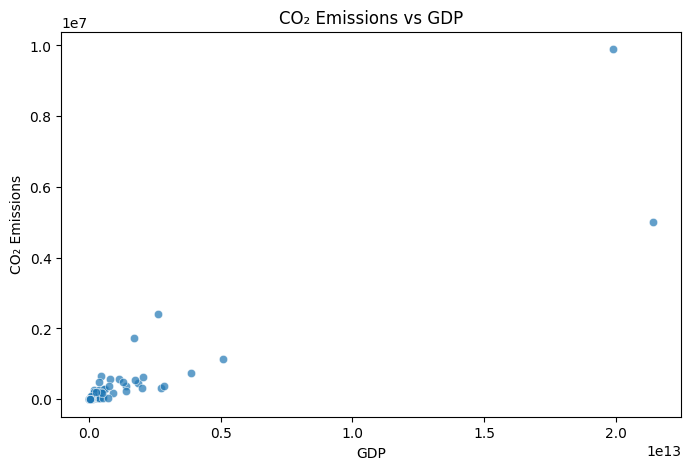

In [39]:
# Graficamos.
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_cg, x="GDP", y="Co2-Emissions", alpha=0.7)
plt.title("CO₂ Emissions vs GDP")
plt.xlabel("GDP")
plt.ylabel("CO₂ Emissions")
plt.show()

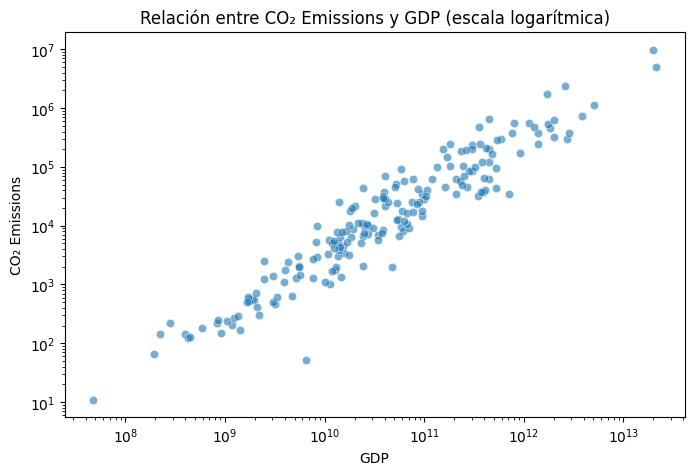

In [38]:
# Graficamos con escala logaritmíca.
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_cg,
    x="GDP",
    y="Co2-Emissions",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("GDP")
plt.ylabel("CO₂ Emissions")
plt.title("Relación entre CO₂ Emissions y GDP (escala logarítmica)")
plt.show()

#### Uso de escala logarítmica:
Se utilizó una escala logarítmica porque tanto el PBI como las emisiones de CO₂ presentan valores muy dispares entre países, distribuidos en varios órdenes de magnitud.
La transformación logarítmica reduce el efecto de los valores extremos, permite visualizar mejor la distribución completa y revela patrones que en escala normal quedan ocultos.
#### Justificación de por qué no se eliminaron los outliers:
Los valores extremadamente altos no son errores ni mediciones anómalas, sino que corresponden a economías muy grandes que, de manera natural, generan niveles de actividad y de emisiones muy superiores al promedio mundial.
Eliminar estos puntos hubiese reducido la variabilidad real del fenómeno e impedido interpretar la relación entre ambas variables a nivel global, ya que los países más desarrollados son justamente los que permiten observar cómo el crecimiento económico se asocia con mayores emisiones.
En consecuencia, se optó por mantener todos los valores y utilizar una escala logarítmica, que permite visualizar la distribución completa sin distorsionar el análisis ni excluir datos que son representativos de la realidad mundial.
#### Conclusión:
Se observó una correlación positiva entre el PBI y las emisiones de CO₂. Esto indica que los países con mayor nivel de actividad económica tienden a emitir más dióxido de carbono.
Si bien la relación no es perfectamente lineal, el patrón general muestra que el crecimiento económico suele estar asociado a mayores emisiones, especialmente en economías dependientes de la industria y los combustibles fósiles. La escala logarítmica permitió revelar claramente esta tendencia.